# Machine Learning-Based Network Intrusion Classification in IoT Environments Using the CICIoT2023 Dataset

**Course:** Machine Learning and Data Mining — IT9201  
**Programme:** Master of Science in Artificial Intelligence  
**Institution:** Bahrain Polytechnic  
**Lecturer:** Dr. Shomona Gracia Jacob  
**Student Name:* Enas Alsawaeer*  
**Student ID:* 12011215*  
**Submission Date:** 27 May 2026

---
## Table of Contents

1. [Libraries and Environment Setup](#1-libraries-and-environment-setup)
2. [Dataset Loading and Description](#2-dataset-loading-and-description)
3. [Exploratory Data Analysis (EDA)](#3-exploratory-data-analysis)
4. [Data Preprocessing](#4-data-preprocessing)
5. [Feature Selection](#5-feature-selection)
6. [Model Training](#6-model-training)
7. [Hyperparameter Optimization](#7-hyperparameter-optimization)
8. [Model Evaluation and Comparison](#8-model-evaluation-and-comparison)
9. [Critical Analysis and Discussion](#9-critical-analysis-and-discussion)

---
## 1. Libraries and Environment Setup

In [39]:
# Libraries
from pathlib import Path
import os, csv, gc

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', lambda x: '%.2f' % x)

---
## 2. Dataset Loading and Description

In [40]:
base_folder = r"C:\Users\enas.alsawaeer\Documents\GitHub\ML_and_DM\CSV\CSV"

In [41]:
FOLDERS = {
    # Benign
    "Benign_Final"           : "Benign",

    # DDoS
    "DDoS-SYN_Flood"         : "DDoS",
    "DDoS-UDP_Flood"         : "DDoS",
    "DDoS-HTTP_Flood"        : "DDoS",
    "DDoS-ICMP_Flood"        : "DDoS",
    "DDoS-TCP_Flood"         : "DDoS",
    "DDoS-RSTFINFLOOD"       : "DDoS",
    "DDoS-PSHACK_FLOOD"      : "DDoS",
    "DDoS-SlowLoris"         : "DDoS",
    "DDoS-SynonymousIP_Flood": "DDoS",
    "DDoS-ACK_Fragmentation" : "DDoS",
    "DDoS-ICMP_Fragmentation": "DDoS",
    "DDoS-UDP_Fragmentation" : "DDoS",

    # DoS
    "DoS-HTTP_Flood"         : "DoS",
    "DoS-SYN_Flood"          : "DoS",
    "DoS-TCP_Flood"          : "DoS",
    "DoS-UDP_Flood"          : "DoS",

    # Mirai
    "Mirai-greeth_flood"     : "Mirai",
    "Mirai-greip_flood"      : "Mirai",
    "Mirai-udpplain"         : "Mirai",

    # Recon
    "Recon-HostDiscovery"    : "Recon",
    "Recon-OSScan"           : "Recon",
    "Recon-PingSweep"        : "Recon",
    "Recon-PortScan"         : "Recon",
    "VulnerabilityScan"      : "Recon",

    # Spoofing
    "DNS_Spoofing"           : "Spoofing",
    "MITM-ArpSpoofing"       : "Spoofing",

    # Web Attacks
    "BrowserHijacking"       : "WebAttack",
    "CommandInjection"       : "WebAttack",
    "SqlInjection"           : "WebAttack",
    "XSS"                    : "WebAttack",

    # Brute Force
    "DictionaryBruteForce"   : "BruteForce",

    # Malware
    "Backdoor_Malware"       : "Malware",

    # Uploading
    "Uploading_Attack"       : "Uploading",
}

In [42]:
all_files = []

for folder_name in FOLDERS:
    folder_path = os.path.join(base_folder, folder_name)
    if os.path.isdir(folder_path):
        for file_name in os.listdir(folder_path):
            if file_name.endswith(".csv") or file_name.endswith(".pcap"):
                all_files.append({
                    "folder" : folder_name,
                    "file"   : file_name,
                    "path"   : os.path.join(folder_path, file_name)
                })

print(f"Total files found across all folders: {len(all_files)}\n")

if len(all_files) == 0:
    print("No files found")
else:
    ref = all_files[0]
    with open(ref["path"], "r", encoding="utf-8", newline="") as f:
        reference_columns = next(csv.reader(f))

    print(f" REFERENCE FILE")
    print(f"   Folder  : {ref['folder']}")
    print(f"   File    : {ref['file']}")
    print(f"   Columns : {len(reference_columns)}")
    print(f"   Names   : {reference_columns}\n")
    print("=" * 65)
    print(f"{'STATUS':<10} {'FOLDER':<30} {'FILE':<30}")
    print("=" * 65)

    all_match = True

    for item in all_files[1:]:
        with open(item["path"], "r", encoding="utf-8", newline="") as f:
            current_columns = next(csv.reader(f))

        if current_columns == reference_columns:
            status = "MATCH"
        else:
            status = "MISMATCH"
            all_match = False
            print(f"{status:<10} {item['folder']:<30} {item['file']:<30}")
            print(f"           Expected {len(reference_columns)} columns, got {len(current_columns)}")
            print(f"           Different columns: {set(current_columns) ^ set(reference_columns)}\n")
            continue

        print(f"{status:<10} {item['folder']:<30} {item['file']:<30}")

    print("=" * 65)
    if all_match:
        print(f"\n ALL {len(all_files)} FILES HAVE IDENTICAL COLUMNS")
    else:
        print(f"\n COLUMN MISMATCH DETECTED")

Total files found across all folders: 309

 REFERENCE FILE
   Folder  : Benign_Final
   File    : BenignTraffic.pcap.csv
   Columns : 39
   Names   : ['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Variance']

STATUS     FOLDER                         FILE                          
MATCH      Benign_Final                   BenignTraffic1.pcap.csv       
MATCH      Benign_Final                   BenignTraffic2.pcap.csv       
MATCH      Benign_Final                   BenignTraffic3.pcap.csv       
MATCH      DDoS-SYN_Flood                 DDoS-SYN_Flood.pcap.csv       
MATCH      DDoS-SYN_Flood                 DDo

In [45]:
# Per-class cap to prevent memory overflow on 32GB RAM
CAP = {
    'DDoS'       : 500_000,
    'DoS'        : 500_000,
    'Mirai'      : 300_000,
    'Benign'     : 200_000,
    'Recon'      : 200_000,
    'Spoofing'   : 200_000,
    'WebAttack'  : None,   # keep all — too small to cap
    'BruteForce' : None,
    'Malware'    : None,
    'Uploading'  : None,
}

all_data = []

for folder_name, label in FOLDERS.items():

    folder_path = os.path.join(base_folder, folder_name)

    all_files = [
        f for f in os.listdir(folder_path)
        if f.endswith(".csv") or f.endswith(".pcap")
    ]

    print(f"Loading : {folder_name}  ({label})")
    print(f"  Files  : {len(all_files)}")

    folder_frames = []
    for file_name in all_files:
        df_temp = pd.read_csv(
            os.path.join(folder_path, file_name),
            low_memory=False
        )
        folder_frames.append(df_temp)

    folder_df = pd.concat(folder_frames, ignore_index=True)
    print(f"  Rows before cap : {len(folder_df):,}")

    folder_df["label_multiclass"] = label
    folder_df["label_binary"]     = 0 if label == "Benign" else 1

    cap = CAP.get(label)
    if cap is not None and len(folder_df) > cap:
        folder_df = folder_df.sample(n=cap, random_state=42)
        print(f"  Rows after cap  : {len(folder_df):,}  (capped to {cap:,})")
    else:
        print(f"  Rows            : {len(folder_df):,}  (kept all)")

    all_data.append(folder_df)
    del folder_frames, df_temp
    gc.collect()

data = pd.concat(all_data, ignore_index=True)
del all_data
gc.collect()

print("" + "=" * 55)
print(f"Dataset shape   : {data.shape}")
print(f"Total rows      : {len(data):,}")
print()
print("Group distribution (label_multiclass):")
print(data["label_multiclass"].value_counts().to_string())
print()
print("Binary distribution (label_binary):")
print(data["label_binary"].value_counts().to_string())

Loading : Benign_Final  (Benign)
  Files  : 4
  Rows before cap : 1,098,191
  Rows after cap  : 200,000  (capped to 200,000)
Loading : DDoS-SYN_Flood  (DDoS)
  Files  : 16
  Rows before cap : 4,059,179
  Rows after cap  : 500,000  (capped to 500,000)
Loading : DDoS-UDP_Flood  (DDoS)
  Files  : 21
  Rows before cap : 5,412,231
  Rows after cap  : 500,000  (capped to 500,000)
Loading : DDoS-HTTP_Flood  (DDoS)
  Files  : 1
  Rows before cap : 28,790
  Rows            : 28,790  (kept all)
Loading : DDoS-ICMP_Flood  (DDoS)
  Files  : 27
  Rows before cap : 7,200,501
  Rows after cap  : 500,000  (capped to 500,000)
Loading : DDoS-TCP_Flood  (DDoS)
  Files  : 18
  Rows before cap : 4,497,649
  Rows after cap  : 500,000  (capped to 500,000)
Loading : DDoS-RSTFINFLOOD  (DDoS)
  Files  : 16
  Rows before cap : 4,045,279
  Rows after cap  : 500,000  (capped to 500,000)
Loading : DDoS-PSHACK_FLOOD  (DDoS)
  Files  : 16
  Rows before cap : 4,094,772
  Rows after cap  : 500,000  (capped to 500,000)


In [46]:
# Convert float64 to float32 — reduces memory usage by ~50%
float_cols = data.select_dtypes(include='float64').columns
data[float_cols] = data[float_cols].astype('float32')

mem_gb = data.memory_usage(deep=True).sum() / 1e9
print(f"Memory after float32 conversion : {mem_gb:.2f} GB")
print(f"Shape                           : {data.shape}")

Memory after float32 conversion : 1.88 GB
Shape                           : (8182541, 41)


---
## 3. Exploratory Data Analysis (EDA)

In [48]:
data.head()

,Header_Length,Protocol Type,Time_To_Live,Rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,...,Min,Max,AVG,Std,Tot size,IAT,Number,Variance,label_multiclass,label_binary
0,18.40,6,81.20,75.08,0.00,0.00,0.00,0.20,0.50,0.00,...,66.00,373.00,231.90,131.89,231.90,0.01,10.00,17395.88,Benign,0
1,32.00,6,64.00,1367.60,0.00,0.00,0.00,0.00,1.00,0.00,...,1514.00,2962.00,2238.00,763.16,2238.00,0.00,10.00,582417.75,Benign,0
2,22.40,6,101.40,50.87,0.00,0.00,0.00,0.20,0.60,0.00,...,66.00,1514.00,466.90,562.42,466.90,0.02,10.00,316314.78,Benign,0
3,31.60,6,69.90,186.13,0.00,0.10,0.00,0.00,0.90,0.00,...,60.00,1514.00,1224.60,610.12,1224.60,0.01,10.00,372243.59,Benign,0
4,32.00,6,214.30,413.17,0.00,0.00,0.00,0.10,1.00,0.00,...,66.00,156.00,75.00,28.46,75.00,0.00,10.00,810.00,Benign,0


In [49]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8182541 entries, 0 to 8182540
Data columns (total 41 columns):
 #   Column            Dtype  
---  ------            -----  
 0   Header_Length     float32
 1   Protocol Type     int64  
 2   Time_To_Live      float32
 3   Rate              float32
 4   fin_flag_number   float32
 5   syn_flag_number   float32
 6   rst_flag_number   float32
 7   psh_flag_number   float32
 8   ack_flag_number   float32
 9   ece_flag_number   float32
 10  cwr_flag_number   float32
 11  ack_count         float32
 12  syn_count         float32
 13  fin_count         float32
 14  rst_count         float32
 15  HTTP              float32
 16  HTTPS             float32
 17  DNS               float32
 18  Telnet            float32
 19  SMTP              float32
 20  SSH               float32
 21  IRC               float32
 22  TCP               float32
 23  UDP               float32
 24  DHCP              float32
 25  ARP               float32
 26  ICMP          

In [50]:
data.dtypes

Header_Length       float32
Protocol Type         int64
Time_To_Live        float32
Rate                float32
fin_flag_number     float32
syn_flag_number     float32
rst_flag_number     float32
psh_flag_number     float32
ack_flag_number     float32
ece_flag_number     float32
cwr_flag_number     float32
ack_count           float32
syn_count           float32
fin_count           float32
rst_count           float32
HTTP                float32
HTTPS               float32
DNS                 float32
Telnet              float32
SMTP                float32
SSH                 float32
IRC                 float32
TCP                 float32
UDP                 float32
DHCP                float32
ARP                 float32
ICMP                float32
IGMP                float32
IPv                 float32
LLC                 float32
Tot sum             float32
Min                 float32
Max                 float32
AVG                 float32
Std                 float32
Tot size            

In [51]:
data.shape

(8182541, 41)

In [52]:
data['label_binary'].unique()

array([0, 1])

In [53]:
data['label_binary'].value_counts()

label_binary
1    7982541
0     200000
Name: count, dtype: int64

In [54]:
data['label_multiclass'].unique()

array(['Benign', 'DDoS', 'DoS', 'Mirai', 'Recon', 'Spoofing', 'WebAttack',
       'BruteForce', 'Malware', 'Uploading'], dtype=object)

In [55]:
data['label_multiclass'].value_counts()

label_multiclass
DDoS          4576706
DoS           1571861
Mirai          900000
Recon          517183
Spoofing       378898
Benign         200000
WebAttack       20359
BruteForce      13064
Malware          3218
Uploading        1252
Name: count, dtype: int64

In [56]:
data.isna().sum()

Header_Length         0
Protocol Type         0
Time_To_Live          0
Rate                  0
fin_flag_number       1
syn_flag_number       1
rst_flag_number       1
psh_flag_number       1
ack_flag_number       1
ece_flag_number       1
cwr_flag_number       1
ack_count             1
syn_count             1
fin_count             1
rst_count             1
HTTP                  1
HTTPS                 1
DNS                   1
Telnet                1
SMTP                  1
SSH                   1
IRC                   1
TCP                   1
UDP                   1
DHCP                  1
ARP                   1
ICMP                  1
IGMP                  1
IPv                   1
LLC                   1
Tot sum               1
Min                   1
Max                   1
AVG                   1
Std                 265
Tot size              1
IAT                   1
Number                1
Variance            265
label_multiclass      0
label_binary          0
dtype: int64

In [57]:
data.notna().sum() 

Header_Length       8182541
Protocol Type       8182541
Time_To_Live        8182541
Rate                8182541
fin_flag_number     8182540
syn_flag_number     8182540
rst_flag_number     8182540
psh_flag_number     8182540
ack_flag_number     8182540
ece_flag_number     8182540
cwr_flag_number     8182540
ack_count           8182540
syn_count           8182540
fin_count           8182540
rst_count           8182540
HTTP                8182540
HTTPS               8182540
DNS                 8182540
Telnet              8182540
SMTP                8182540
SSH                 8182540
IRC                 8182540
TCP                 8182540
UDP                 8182540
DHCP                8182540
ARP                 8182540
ICMP                8182540
IGMP                8182540
IPv                 8182540
LLC                 8182540
Tot sum             8182540
Min                 8182540
Max                 8182540
AVG                 8182540
Std                 8182276
Tot size            

In [58]:
data.describe()

C:\Users\enas.alsawaeer\.conda\envs\gpu_env\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,Header_Length,Protocol Type,Time_To_Live,Rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,...,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Variance,label_binary
count,8182541.00,8182541.00,8182541.00,8182541.00,8182540.00,8182540.00,8182540.00,8182540.00,8182540.00,8182540.00,...,8182540.00,8182540.00,8182540.00,8182540.00,8182276.00,8182540.00,8182540.00,8182540.00,8182276.00,8182541.00
mean,14.27,10.82,69.62,inf,0.06,0.20,0.08,0.09,0.18,0.00,...,22310.75,104.58,491.03,274.50,133.46,274.50,0.03,87.41,94091.75,0.98
std,9.46,11.34,21.36,NaN,0.24,0.38,0.25,0.24,0.34,0.00,...,30405.21,158.50,819.94,358.78,276.19,358.78,24.37,31.17,452183.91,0.15
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,60.00,42.00,46.00,46.00,0.00,46.00,0.00,1.00,0.00,0.00
25%,7.92,6.00,64.00,2658.83,0.00,0.00,0.00,0.00,0.00,0.00,...,6000.00,60.00,60.00,60.00,0.00,60.00,0.00,100.00,0.00,1.00
50%,19.88,6.00,64.00,13584.79,0.00,0.00,0.00,0.00,0.00,0.00,...,6000.00,60.00,66.00,60.10,0.00,60.10,0.00,100.00,0.00,1.00
75%,20.00,17.00,64.64,30646.68,0.00,0.02,0.00,0.00,0.10,0.00,...,18200.00,60.00,578.00,550.42,72.28,550.42,0.00,100.00,5224.93,1.00
max,60.00,47.00,255.00,inf,1.00,1.00,1.00,1.00,1.00,1.00,...,308732.00,4895.00,47850.00,7016.40,9730.18,7016.40,46665.21,100.00,94676392.00,1.00


In [59]:
for col in data.columns:
    non_numeric = pd.to_numeric(data[col], errors="coerce").isna().sum() - data[col].isna().sum()
    print(col, "->", non_numeric)

Header_Length -> 0
Protocol Type -> 0
Time_To_Live -> 0
Rate -> 0
fin_flag_number -> 0
syn_flag_number -> 0
rst_flag_number -> 0
psh_flag_number -> 0
ack_flag_number -> 0
ece_flag_number -> 0
cwr_flag_number -> 0
ack_count -> 0
syn_count -> 0
fin_count -> 0
rst_count -> 0
HTTP -> 0
HTTPS -> 0
DNS -> 0
Telnet -> 0
SMTP -> 0
SSH -> 0
IRC -> 0
TCP -> 0
UDP -> 0
DHCP -> 0
ARP -> 0
ICMP -> 0
IGMP -> 0
IPv -> 0
LLC -> 0
Tot sum -> 0
Min -> 0
Max -> 0
AVG -> 0
Std -> 0
Tot size -> 0
IAT -> 0
Number -> 0
Variance -> 0
label_multiclass -> 8182541
label_binary -> 0


In [60]:
data.shape

(8182541, 41)

In [61]:
numeric_data = data.select_dtypes(include="number")

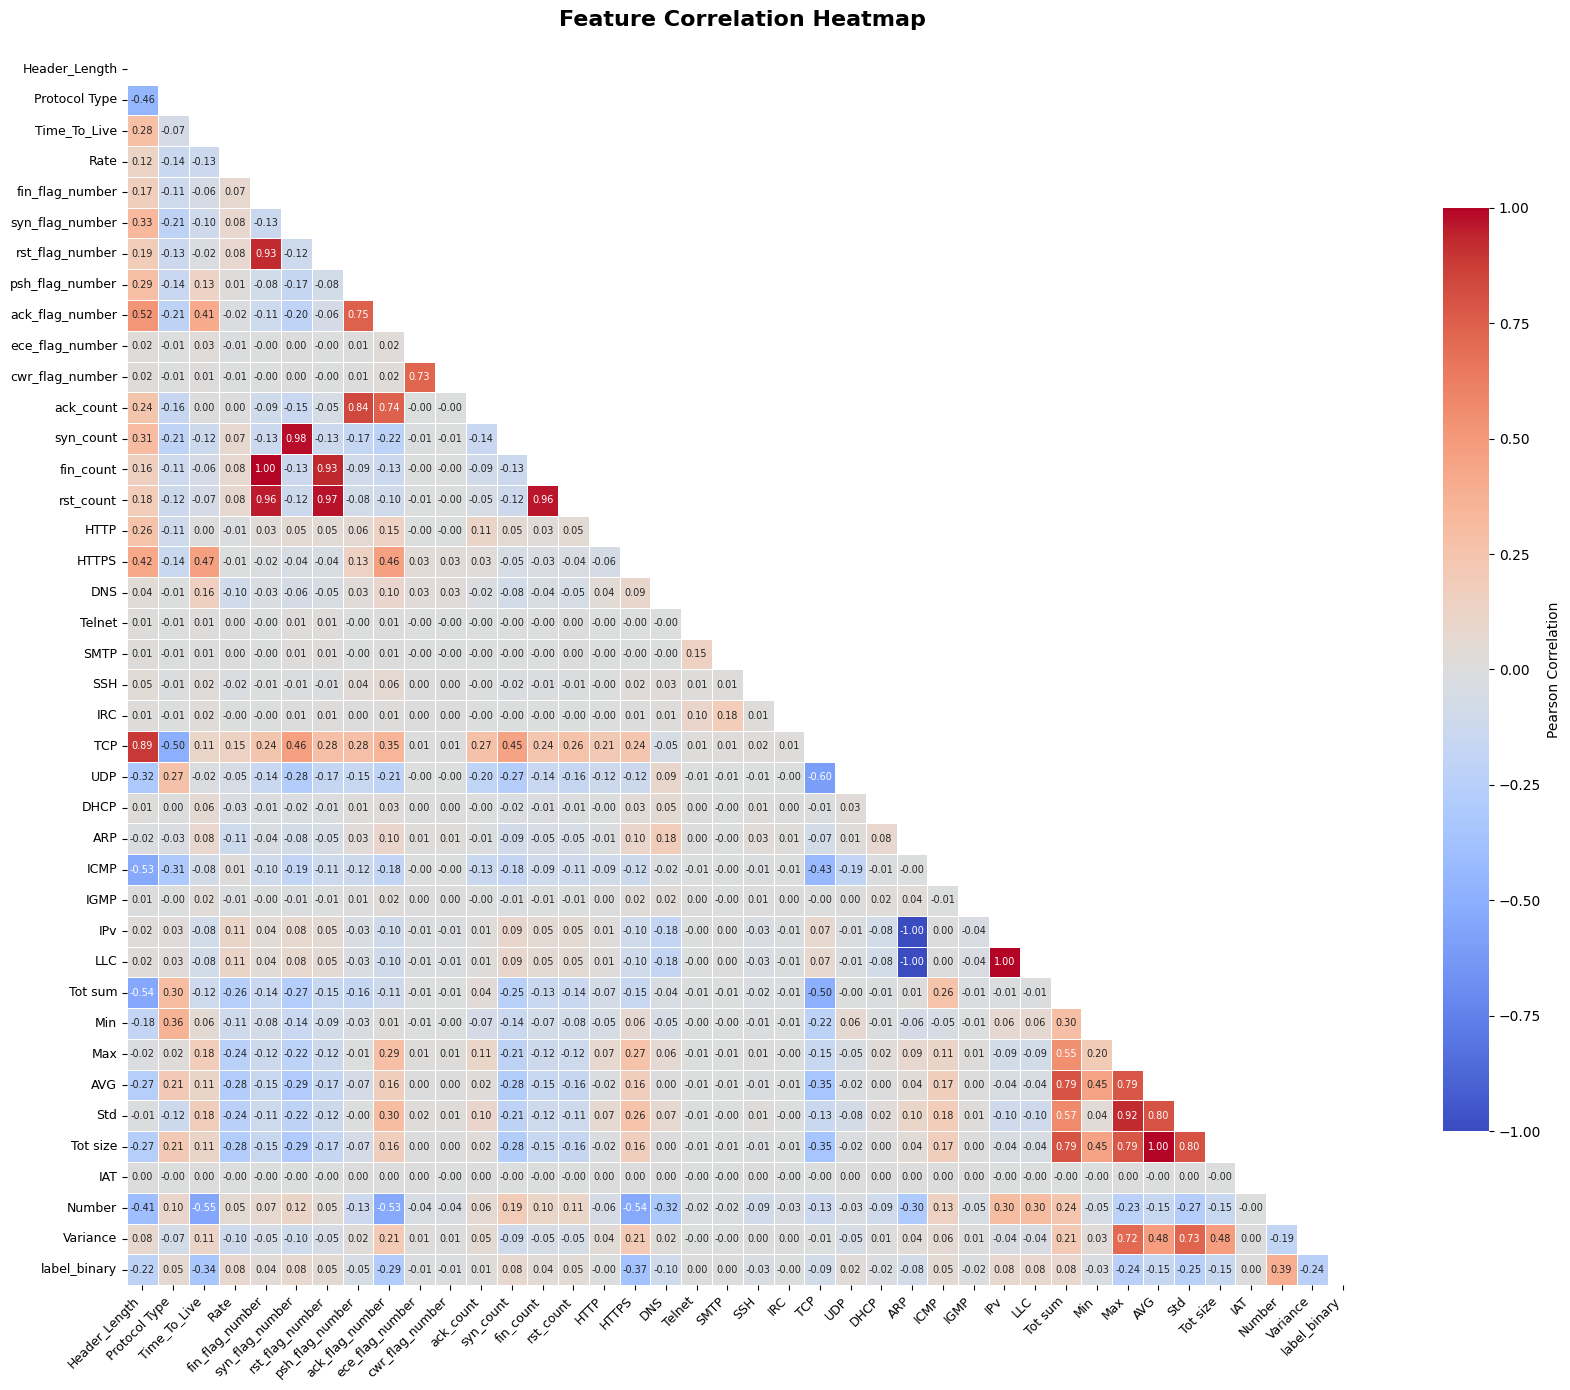

In [62]:
corr_matrix = numeric_data.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(18, 14))

sns.heatmap(
    corr_matrix,
    mask=mask,                  
    annot=True,                 
    fmt=".2f",                  
    cmap="coolwarm",            
    center=0,                  
    vmin=-1, vmax=1,
    linewidths=0.4,             
    linecolor='white',
    square=True,                
    cbar_kws={"shrink": 0.75, "label": "Pearson Correlation"},
    annot_kws={"size": 7},       
    ax=ax
)

ax.set_title("Feature Correlation Heatmap",
             fontsize=16, fontweight='bold', pad=20)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

In [63]:
import requests
from notion_client import Client

NOTION_TOKEN = "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"
DATABASE_ID  = "5474759593d54a148f1541dea61de174"

headers = {
    "Authorization": f"Bearer {NOTION_TOKEN}",
    "Content-Type": "application/json",
    "Notion-Version": "2022-06-28"
}

def track():
    # Fetch all tasks sorted by due date
    response = requests.post(
        f"https://api.notion.com/v1/databases/{DATABASE_ID}/query",
        headers=headers,
        json={"page_size": 100,
              "sorts": [{"property": "Due Date", "direction": "ascending"}]}
    )

    pages = response.json().get("results", [])

    task_list = []
    for page in pages:
        try:
            title = page["properties"]["Task"]["title"]
            due   = page["properties"]["Due Date"]["date"]
            if title:
                task_list.append({
                    "name"  : title[0]["text"]["content"],
                    "id"    : page["id"],
                    "status": page["properties"]["Status"]["select"]["name"]
                              if page["properties"]["Status"]["select"] else "—",
                    "due"   : due["start"] if due else "No date"
                })
        except:
            pass

    print("\n" + "="*70)
    print("          📋 ML PROJECT TASK TRACKER  —  sorted by due date")
    print("="*70)
    for i, task in enumerate(task_list, 1):
        icon = "✅" if task["status"] == "Done" else "⬜"
        print(f"  {i:>2}. {icon} [{task['due']}]  {task['name']}")
    print("="*70)

    choice = input("\nEnter task number to mark as DONE (or 0 to cancel): ").strip()

    if choice == "0":
        print("Cancelled.")
    else:
        try:
            selected = task_list[int(choice) - 1]
            requests.patch(
                f"https://api.notion.com/v1/pages/{selected['id']}",
                headers=headers,
                json={"properties": {"Status": {"select": {"name": "Done"}}}}
            )
            print(f"\n✅ Marked as Done: {selected['name']}")
        except (IndexError, ValueError):
            print("❌ Invalid number. Try again.")

print("✅ Setup complete — call track() anytime you finish a task")

✅ Setup complete — call track() anytime you finish a task


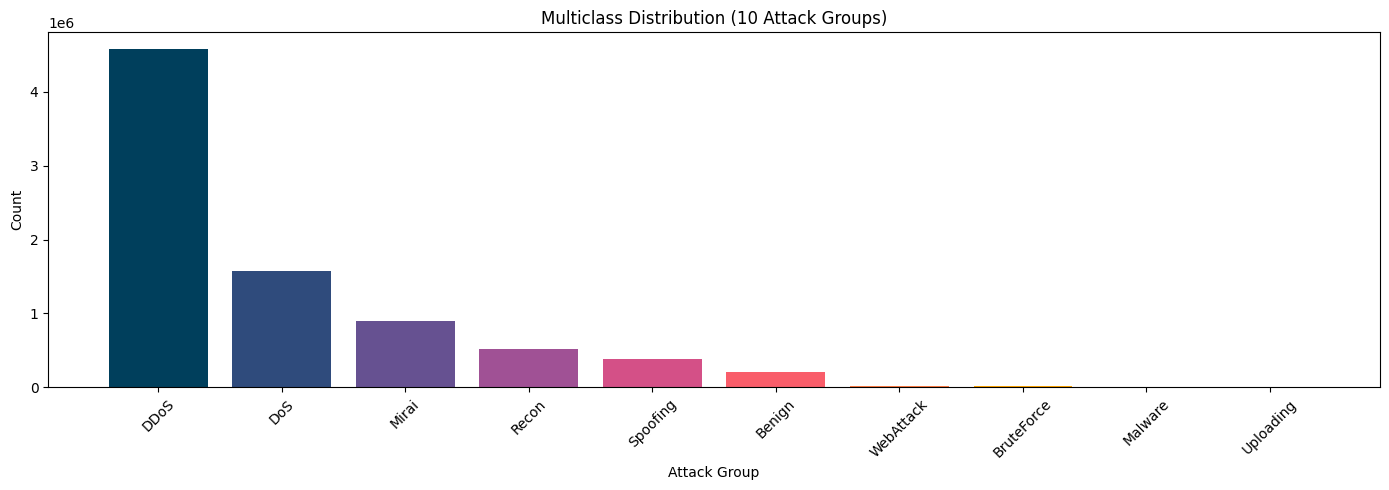

In [64]:
counts = data["label_multiclass"].value_counts()

colors = [
    "#003f5c", "#2f4b7c", "#665191", "#a05195",
    "#d45087", "#f95d6a", "#ff7c43", "#ffa600",
    "#488f31", "#6ab187"
]

plt.figure(figsize=(14, 5))
plt.bar(counts.index, counts.values, color=colors[:len(counts)])
plt.title("Multiclass Distribution (10 Attack Groups)")
plt.xlabel("Attack Group")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

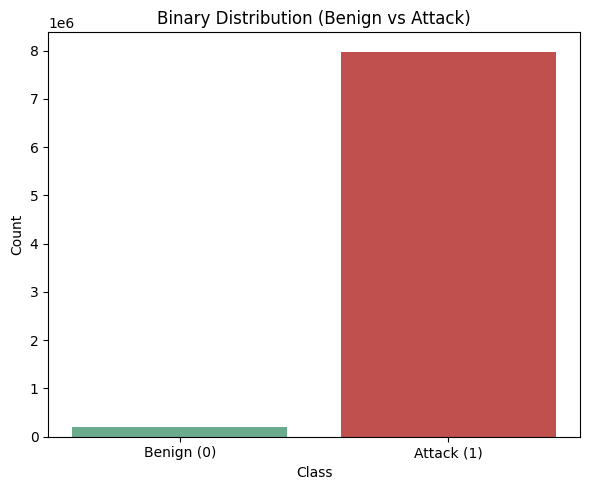

In [65]:
counts = data["label_binary"].value_counts().sort_index()

plt.figure(figsize=(6, 5))
plt.bar(["Benign (0)", "Attack (1)"], counts.values, color=["#6aab8e", "#c0504d"])
plt.title("Binary Distribution (Benign vs Attack)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [66]:
base_folder = r"C:\Users\enas.alsawaeer\Documents\GitHub\ML_and_DM\CSV\CSV"

folders = sorted(os.listdir(base_folder))

print(f"{'Folder':<35} {'Files':>6} {'Total Rows':>15} {'Size MB':>10}")
print("=" * 70)

grand_total = 0
for folder_name in folders:
    folder_path = os.path.join(base_folder, folder_name)
    if not os.path.isdir(folder_path):
        continue

    files = [f for f in os.listdir(folder_path)
             if f.endswith(".csv") or f.endswith(".pcap")]

    total_rows = 0
    total_size = 0
    for f in files:
        fp = os.path.join(folder_path, f)
        total_size += os.path.getsize(fp) / (1024*1024)
        with open(fp, "r", encoding="utf-8", errors="ignore") as file:
            total_rows += sum(1 for _ in file) - 1

    grand_total += total_rows
    print(f"{folder_name:<35} {len(files):>6} {total_rows:>15,} {total_size:>9.1f}")

print("=" * 70)
print(f"{'TOTAL':<35} {grand_total:>36,}")

Folder                               Files      Total Rows    Size MB
Backdoor_Malware                         1           3,218       0.6
Benign_Final                             4       1,098,191     216.9
BrowserHijacking                         1           5,859       1.2
CommandInjection                         1           5,409       1.1
DDoS-ACK_Fragmentation                  13         285,075      59.9
DDoS-HTTP_Flood                          1          28,790       6.2
DDoS-ICMP_Flood                         27       7,200,501    1264.8
DDoS-ICMP_Fragmentation                 20         452,490      95.1
DDoS-PSHACK_FLOOD                       16       4,094,772     733.9
DDoS-RSTFINFLOOD                        16       4,045,279     731.5
DDoS-SYN_Flood                          16       4,059,179     738.4
DDoS-SlowLoris                           1          23,426       5.0
DDoS-SynonymousIP_Flood                 14       3,598,133     643.4
DDoS-TCP_Flood                   

---
## 4. Data Preprocessing

### Step 1 - Handle Missing Values and Infinity

In [67]:
# Step 1: Handle Infinity and Missing Values
numeric_cols = [c for c in data.select_dtypes(include='number').columns
                if c not in ['label_binary']]

print('=' * 55)
print(f"{'Column':<25} {'Inf':>10} {'NaN':>10}")
print('=' * 55)

for col in numeric_cols:
    n_inf = np.isinf(data[col]).sum()
    n_nan = data[col].isna().sum()
    if n_inf > 0 or n_nan > 0:
        print(f"{col:<25} {n_inf:>10,} {n_nan:>10,}")

print('=' * 55)

data.replace([np.inf, -np.inf], np.nan, inplace=True)

for col in numeric_cols:
    data[col] = data[col].fillna(data[col].median())

print(f"Inf  remaining : {np.isinf(data[numeric_cols].values).sum()}")
print(f"NaN  remaining : {data[numeric_cols].isna().sum().sum()}")
print(f"Dataset shape  : {data.shape}")

# Recompute correlation matrix on clean data (post inf/NaN handling)
corr_matrix = data[numeric_cols].corr()
print('\nCorrelation matrix recomputed on clean data.')

Column                           Inf        NaN
Rate                             330          0
fin_flag_number                    0          1
syn_flag_number                    0          1
rst_flag_number                    0          1
psh_flag_number                    0          1
ack_flag_number                    0          1
ece_flag_number                    0          1
cwr_flag_number                    0          1
ack_count                          0          1
syn_count                          0          1
fin_count                          0          1
rst_count                          0          1
HTTP                               0          1
HTTPS                              0          1
DNS                                0          1
Telnet                             0          1
SMTP                               0          1
SSH                                0          1
IRC                                0          1
TCP                                0    

### Step 2 - Correlation-Based Feature Selection

Explore different correlation thresholds to identify the best cutoff, then drop the most redundant features.

In [69]:
for threshold in [0.70, 0.75, 0.80, 0.85, 0.90, 0.95]:
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    pairs = (upper.abs() > threshold).sum().sum()
    print(f"Threshold {threshold}: {pairs} highly correlated pairs")

Threshold 0.7: 25 highly correlated pairs
Threshold 0.75: 20 highly correlated pairs
Threshold 0.8: 14 highly correlated pairs
Threshold 0.85: 13 highly correlated pairs
Threshold 0.9: 12 highly correlated pairs
Threshold 0.95: 9 highly correlated pairs


In [70]:
threshold = 0.85

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col].abs() > threshold)]

print(f"Dropping {len(to_drop)} features: {to_drop}")
data_reduced = data.drop(columns=to_drop)
print(f"Remaining features: {data_reduced.shape[1]}")

Dropping 9 features: ['rst_flag_number', 'syn_count', 'fin_count', 'rst_count', 'TCP', 'IPv', 'LLC', 'Std', 'Tot size']
Remaining features: 32


### Step 3 - Train / Test Split and Feature Scaling

In [71]:
from sklearn.model_selection import train_test_split

feature_cols = [c for c in data_reduced.columns
                if c not in ['label_binary', 'label_multiclass']]

X            = data_reduced[feature_cols].reset_index(drop=True)
y_binary     = data_reduced['label_binary'].reset_index(drop=True)
y_multiclass = data_reduced['label_multiclass'].reset_index(drop=True)

X_train, X_test, y_train_bin, y_test_bin, y_train_multi, y_test_multi = train_test_split(
    X, y_binary, y_multiclass,
    test_size=0.2,
    random_state=42,
    stratify=y_multiclass    # ensures proportional class split
)

print(f"Train set : {X_train.shape[0]:,} rows  |  {X_train.shape[1]} features")
print(f"Test set  : {X_test.shape[0]:,} rows  |  {X_test.shape[1]} features")
print()
print("Train — Multiclass distribution:")
print(y_train_multi.value_counts().to_string())
print()
print("Train — Binary distribution:")
print(y_train_bin.value_counts().to_string())

Train set : 6,546,032 rows  |  30 features
Test set  : 1,636,509 rows  |  30 features

Train — Multiclass distribution:
label_multiclass
DDoS          3661364
DoS           1257489
Mirai          720000
Recon          413746
Spoofing       303118
Benign         160000
WebAttack       16287
BruteForce      10451
Malware          2575
Uploading        1002

Train — Binary distribution:
label_binary
1    6386032
0     160000


In [72]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_cols
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_cols
)

print("StandardScaler applied — fit on training set only.")
print(f"X_train_scaled shape : {X_train_scaled.shape}")
print(f"X_test_scaled shape  : {X_test_scaled.shape}")

StandardScaler applied — fit on training set only.
X_train_scaled shape : (6546032, 30)
X_test_scaled shape  : (1636509, 30)


### Step 4 - Handling Class Imbalance (SMOTE on Training Set Only)

**Strategy:** SMOTE oversampling is applied **only on the training set** to synthetically generate samples for critically underrepresented classes. The test set remains untouched to preserve evaluation integrity.

In [73]:
from imblearn.over_sampling import SMOTE

print('Before SMOTE - Training multiclass distribution:')
print(y_train_multi.value_counts().to_string())
print()

# Oversample only critically underrepresented classes (training set only)
oversample_strategy = {
    'WebAttack'  : 50_000,
    'BruteForce' : 50_000,
    'Malware'    : 10_000,
    'Uploading'  :  5_000,
}

smote = SMOTE(
    sampling_strategy=oversample_strategy,
    random_state=42,
    k_neighbors=3    # low k - Malware/Uploading have very few real samples
)

X_resampled_arr, y_train_multi_resampled = smote.fit_resample(
    X_train_scaled, y_train_multi
)

# Convert back to DataFrame to preserve column names for downstream steps
X_train_resampled       = pd.DataFrame(X_resampled_arr, columns=feature_cols)
y_train_multi_resampled = pd.Series(y_train_multi_resampled).reset_index(drop=True)

print('After SMOTE - Training multiclass distribution:')
print(y_train_multi_resampled.value_counts().to_string())

Before SMOTE — Training multiclass distribution:
label_multiclass
DDoS          3661364
DoS           1257489
Mirai          720000
Recon          413746
Spoofing       303118
Benign         160000
WebAttack       16287
BruteForce      10451
Malware          2575
Uploading        1002

After SMOTE — Training multiclass distribution:
label_multiclass
DDoS          3661364
DoS           1257489
Mirai          720000
Recon          413746
Spoofing       303118
Benign         160000
WebAttack       50000
BruteForce      50000
Malware         10000
Uploading        5000


In [74]:
# Rebuild binary labels to match the resampled multiclass training set
y_train_bin_resampled = y_train_multi_resampled.map(
    lambda x: 0 if x == 'Benign' else 1
).reset_index(drop=True)

print('After SMOTE - Final Training Distribution:')
print()
print('  Multiclass:')
print(y_train_multi_resampled.value_counts().to_string())
print()
print('  Binary:')
print(y_train_bin_resampled.value_counts().to_string())
print()
print(f'X_train_resampled shape : {X_train_resampled.shape}')
print(f'X_test_scaled shape     : {X_test_scaled.shape}')

After SMOTE — Final Training Distribution:

  Multiclass:
label_multiclass
DDoS          3661364
DoS           1257489
Mirai          720000
Recon          413746
Spoofing       303118
Benign         160000
WebAttack       50000
BruteForce      50000
Malware         10000
Uploading        5000

  Binary:
label_multiclass
1    6470717
0     160000

X_train_resampled shape : (6630717, 30)
X_test_scaled shape     : (1636509, 30)


---
## 5. Feature Selection

Rank features by importance using a Random Forest trained on resampled training data, then retain only features with importance > 1%.

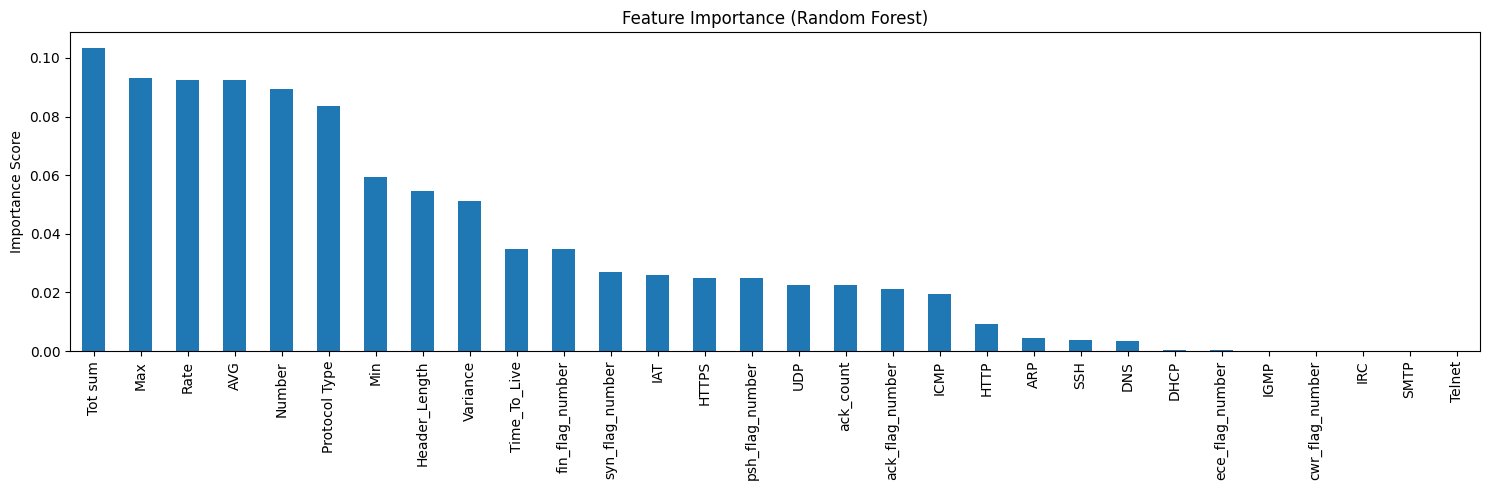

Selected 19 features from 30
X_train_final shape : (6630717, 19)
X_test_final shape  : (1636509, 19)


In [75]:
from sklearn.ensemble import RandomForestClassifier

# Quick Random Forest to rank feature importance on resampled training data
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_train_resampled, y_train_multi_resampled)

importance = pd.Series(rf_selector.feature_importances_, index=feature_cols)
importance = importance.sort_values(ascending=False)

importance.plot(kind='bar', figsize=(15, 5))
plt.title('Feature Importance (Random Forest)')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

# Retain only features with importance above 1%
selected_features = importance[importance > 0.01].index.tolist()
print(f'Selected {len(selected_features)} features from {X_train_resampled.shape[1]}')

X_train_final = X_train_resampled[selected_features]
X_test_final  = X_test_scaled[selected_features]

print(f'X_train_final shape : {X_train_final.shape}')
print(f'X_test_final shape  : {X_test_final.shape}')

---
## 6. Model Training

Five classifiers are trained for both binary and multiclass tasks:
- **Logistic Regression** — interpretable linear baseline
- **Random Forest** — ensemble tree-based method
- **XGBoost** — gradient boosted trees, strong on tabular data
- **LightGBM** — fast gradient boosting, efficient on large datasets
- **MindSpore MLP** — deep learning multi-layer perceptron

All models use `X_train_final` / `X_test_final` (post feature selection).

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import time

# XGBoost requires integer-encoded labels for multiclass
le = LabelEncoder()
y_train_multi_enc = le.fit_transform(y_train_multi_resampled)
y_test_multi_enc  = le.transform(y_test_multi)

print("Classes:", list(le.classes_))

### 6.1 - Binary Classification (Benign vs Attack)

In [ ]:
binary_models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, solver='saga', n_jobs=-1, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42),
    'XGBoost'             : XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=42, n_jobs=-1),
    'LightGBM'            : LGBMClassifier(n_estimators=100, random_state=42, n_jobs=-1, verbose=-1),
}

binary_results = {}

print('=' * 60)
print('BINARY CLASSIFICATION')
print('=' * 60)

for name, model in binary_models.items():
    t0 = time.time()
    model.fit(X_train_final, y_train_bin_resampled)
    elapsed = time.time() - t0

    y_pred = model.predict(X_test_final)
    acc    = accuracy_score(y_test_bin, y_pred)

    binary_results[name] = {
        'model'  : model,
        'y_pred' : y_pred,
        'acc'    : acc,
        'time'   : elapsed,
    }

    print(f"\n{name}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Time     : {elapsed:.1f}s")

print('\nBinary training complete.')

### 6.2 - Multiclass Classification (10 Attack Categories)

In [ ]:
multiclass_models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, solver='saga', n_jobs=-1, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42),
    'XGBoost'             : XGBClassifier(n_estimators=100, eval_metric='mlogloss', random_state=42, n_jobs=-1),
    'LightGBM'            : LGBMClassifier(n_estimators=100, random_state=42, n_jobs=-1, verbose=-1),
}

multiclass_results = {}

print('=' * 60)
print('MULTICLASS CLASSIFICATION')
print('=' * 60)

for name, model in multiclass_models.items():
    t0 = time.time()

    if name == 'XGBoost':
        # XGBoost needs integer-encoded labels
        model.fit(X_train_final, y_train_multi_enc)
        y_pred_enc = model.predict(X_test_final)
        y_pred = le.inverse_transform(y_pred_enc)
    else:
        # LR, RF, LightGBM handle string labels directly
        model.fit(X_train_final, y_train_multi_resampled)
        y_pred = model.predict(X_test_final)

    elapsed = time.time() - t0
    acc     = accuracy_score(y_test_multi, y_pred)

    multiclass_results[name] = {
        'model'  : model,
        'y_pred' : y_pred,
        'acc'    : acc,
        'time'   : elapsed,
    }

    print(f"\n{name}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Time     : {elapsed:.1f}s")

print('\nMulticlass training complete.')

### 6.3 - MindSpore Neural Network (MLP)

> **Install:** `pip install mindspore`  
> MindSpore uses PyNative (eager) mode here for simplicity.

A multi-layer perceptron is trained for both binary and multiclass tasks.
Architecture: `Input → Dense(256) → ReLU → Dropout → Dense(128) → ReLU → Dropout → Dense(64) → ReLU → Output`

In [ ]:
import mindspore
import mindspore.nn as nn
from mindspore import Tensor, set_seed
from mindspore.common import dtype as mstype
from mindspore import value_and_grad

set_seed(42)
mindspore.set_context(mode=mindspore.PYNATIVE_MODE, device_target='CPU')

# ── MLP Architecture ─────────────────────────────────────────────────────
class MLP(nn.Cell):
    def __init__(self, input_dim, hidden_dims, output_dim, dropout=0.3):
        super(MLP, self).__init__()
        layers = []
        in_d = input_dim
        for h in hidden_dims:
            layers += [
                nn.Dense(in_d, h),
                nn.ReLU(),
                nn.Dropout(keep_prob=1.0 - dropout)
            ]
            in_d = h
        layers.append(nn.Dense(in_d, output_dim))
        self.net = nn.SequentialCell(layers)

    def construct(self, x):
        return self.net(x)

# ── Training Helper ──────────────────────────────────────────────────────
def train_ms(X_tr, y_tr, X_te, n_classes,
             hidden_dims=(256, 128, 64), lr=0.001,
             epochs=20, batch_size=2048):

    model     = MLP(X_tr.shape[1], list(hidden_dims), n_classes)
    loss_fn   = nn.CrossEntropyLoss()
    optimizer = nn.Adam(model.trainable_params(), learning_rate=lr)

    def forward_fn(x, y):
        return loss_fn(model(x), y)

    grad_fn = value_and_grad(forward_fn, None, optimizer.parameters)
    model.set_train(True)
    n = X_tr.shape[0]

    for epoch in range(epochs):
        idx = np.random.permutation(n)
        total_loss, n_batches = 0.0, 0
        for start in range(0, n, batch_size):
            b   = idx[start:start + batch_size]
            x_t = Tensor(X_tr[b], mstype.float32)
            y_t = Tensor(y_tr[b], mstype.int32)
            loss, grads = grad_fn(x_t, y_t)
            optimizer(grads)
            total_loss += float(loss.asnumpy())
            n_batches  += 1
        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1:3d}/{epochs}  loss={total_loss/n_batches:.4f}")

    model.set_train(False)
    logits = model(Tensor(X_te, mstype.float32))
    preds  = logits.asnumpy().argmax(axis=1)
    return model, preds

print("MindSpore version:", mindspore.__version__)
print("MLP class and train_ms helper ready.")

In [ ]:
# Prepare numpy arrays for MindSpore
X_tr_np     = X_train_final.values.astype(np.float32)
X_te_np     = X_test_final.values.astype(np.float32)
y_tr_bin_np = y_train_bin_resampled.values.astype(np.int32)

print("Training MindSpore MLP — Binary")
t0 = time.time()
ms_bin_model, y_pred_ms_bin = train_ms(
    X_tr_np, y_tr_bin_np, X_te_np, n_classes=2
)
elapsed = time.time() - t0

acc_ms_bin = accuracy_score(y_test_bin, y_pred_ms_bin)
binary_results['MindSpore MLP'] = {
    'model'  : ms_bin_model,
    'y_pred' : y_pred_ms_bin,
    'acc'    : acc_ms_bin,
    'time'   : elapsed,
}
print(f"Accuracy : {acc_ms_bin:.4f}  ({elapsed:.1f}s)")

In [ ]:
# Multiclass: use integer-encoded labels (same encoder as XGBoost)
y_tr_multi_np = y_train_multi_enc.astype(np.int32)
n_classes_ms  = len(le.classes_)

print("Training MindSpore MLP — Multiclass")
t0 = time.time()
ms_multi_model, y_pred_ms_multi_enc = train_ms(
    X_tr_np, y_tr_multi_np, X_te_np, n_classes=n_classes_ms
)
elapsed = time.time() - t0

# Decode integer predictions back to class names
y_pred_ms_multi = le.inverse_transform(y_pred_ms_multi_enc)
acc_ms_multi = accuracy_score(y_test_multi, y_pred_ms_multi)

multiclass_results['MindSpore MLP'] = {
    'model'  : ms_multi_model,
    'y_pred' : y_pred_ms_multi,
    'acc'    : acc_ms_multi,
    'time'   : elapsed,
}
print(f"Accuracy : {acc_ms_multi:.4f}  ({elapsed:.1f}s)")

---
## 7. Hyperparameter Optimization

`RandomizedSearchCV` (10 iterations, 3-fold CV) is applied to both **XGBoost** and **LightGBM**
for binary and multiclass tasks. The best estimator from each search is evaluated on the test set.

### 7.1 - Tuning XGBoost — Binary

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [3, 5, 7, 9],
    'learning_rate'    : [0.01, 0.05, 0.1, 0.2],
    'subsample'        : [0.6, 0.8, 1.0],
    'colsample_bytree' : [0.6, 0.8, 1.0],
    'min_child_weight' : [1, 3, 5],
}

xgb_bin = XGBClassifier(eval_metric="logloss", random_state=42, n_jobs=-1)

rs_binary = RandomizedSearchCV(
    xgb_bin,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

rs_binary.fit(X_train_final, y_train_bin_resampled)

print(f'Best params  : {rs_binary.best_params_}')
print(f'Best CV F1   : {rs_binary.best_score_:.4f}')

best_xgb_bin  = rs_binary.best_estimator_
y_pred_bin_tuned = best_xgb_bin.predict(X_test_final)
print(f'Test Accuracy: {accuracy_score(y_test_bin, y_pred_bin_tuned):.4f}')

### 7.2 - Tuning LightGBM — Binary

In [ ]:
lgbm_param_dist = {
    'n_estimators'       : [100, 200, 300],
    'max_depth'          : [3, 5, 7, -1],
    'learning_rate'      : [0.01, 0.05, 0.1, 0.2],
    'subsample'          : [0.6, 0.8, 1.0],
    'colsample_bytree'   : [0.6, 0.8, 1.0],
    'num_leaves'         : [31, 63, 127],
    'min_child_samples'  : [20, 50, 100],
}

lgbm_bin = LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)

rs_lgbm_binary = RandomizedSearchCV(
    lgbm_bin,
    param_distributions=lgbm_param_dist,
    n_iter=10,
    cv=3,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

rs_lgbm_binary.fit(X_train_final, y_train_bin_resampled)

print(f'Best params  : {rs_lgbm_binary.best_params_}')
print(f'Best CV F1   : {rs_lgbm_binary.best_score_:.4f}')

best_lgbm_bin     = rs_lgbm_binary.best_estimator_
y_pred_lgbm_bin   = best_lgbm_bin.predict(X_test_final)
print(f'Test Accuracy: {accuracy_score(y_test_bin, y_pred_lgbm_bin):.4f}')

### 7.3 - Tuning XGBoost — Multiclass

In [ ]:
xgb_multi = XGBClassifier(eval_metric="mlogloss", random_state=42, n_jobs=-1)

rs_multi = RandomizedSearchCV(
    xgb_multi,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

rs_multi.fit(X_train_final, y_train_multi_enc)

print(f'Best params  : {rs_multi.best_params_}')
print(f'Best CV F1   : {rs_multi.best_score_:.4f}')

best_xgb_multi       = rs_multi.best_estimator_
y_pred_multi_enc_tuned = best_xgb_multi.predict(X_test_final)
y_pred_multi_tuned   = le.inverse_transform(y_pred_multi_enc_tuned)
print(f'Test Accuracy: {accuracy_score(y_test_multi, y_pred_multi_tuned):.4f}')

### 7.4 - Tuning LightGBM — Multiclass

In [ ]:
# LightGBM handles string labels directly — no encoding needed
lgbm_multi = LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)

rs_lgbm_multi = RandomizedSearchCV(
    lgbm_multi,
    param_distributions=lgbm_param_dist,
    n_iter=10,
    cv=3,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

rs_lgbm_multi.fit(X_train_final, y_train_multi_resampled)

print(f'Best params  : {rs_lgbm_multi.best_params_}')
print(f'Best CV F1   : {rs_lgbm_multi.best_score_:.4f}')

best_lgbm_multi   = rs_lgbm_multi.best_estimator_
y_pred_lgbm_multi = best_lgbm_multi.predict(X_test_final)
print(f'Test Accuracy: {accuracy_score(y_test_multi, y_pred_lgbm_multi):.4f}')

### 7.5 - Tuning MindSpore MLP Architecture

MindSpore does not integrate with `RandomizedSearchCV`.
A manual grid search is performed over hidden layer configurations and learning rates.

In [ ]:
# Manual grid search — Binary
configs = [
    {'hidden_dims': (128, 64),        'lr': 0.001},
    {'hidden_dims': (256, 128, 64),   'lr': 0.001},
    {'hidden_dims': (256, 128, 64),   'lr': 0.01},
    {'hidden_dims': (512, 256, 128),  'lr': 0.001},
]

best_bin_acc, best_bin_cfg = 0, None

print("Binary MLP grid search:")
for cfg in configs:
    _, preds = train_ms(X_tr_np, y_tr_bin_np, X_te_np, n_classes=2,
                        hidden_dims=cfg["hidden_dims"], lr=cfg["lr"], epochs=15)
    acc = accuracy_score(y_test_bin, preds)
    print(f"  hidden={cfg['hidden_dims']}  lr={cfg['lr']}  acc={acc:.4f}")
    if acc > best_bin_acc:
        best_bin_acc, best_bin_cfg = acc, cfg

print(f"\nBest binary config : {best_bin_cfg}  (acc={best_bin_acc:.4f})")

# Retrain with best config
best_ms_bin_model, y_pred_ms_bin_tuned = train_ms(
    X_tr_np, y_tr_bin_np, X_te_np, n_classes=2,
    hidden_dims=best_bin_cfg["hidden_dims"],
    lr=best_bin_cfg["lr"], epochs=20
)
print(f"Tuned Binary Accuracy : {accuracy_score(y_test_bin, y_pred_ms_bin_tuned):.4f}")

In [ ]:
# Manual grid search — Multiclass
best_multi_acc, best_multi_cfg = 0, None

print("Multiclass MLP grid search:")
for cfg in configs:
    _, preds_enc = train_ms(X_tr_np, y_tr_multi_np, X_te_np, n_classes=n_classes_ms,
                            hidden_dims=cfg["hidden_dims"], lr=cfg["lr"], epochs=15)
    preds = le.inverse_transform(preds_enc)
    acc   = accuracy_score(y_test_multi, preds)
    print(f"  hidden={cfg['hidden_dims']}  lr={cfg['lr']}  acc={acc:.4f}")
    if acc > best_multi_acc:
        best_multi_acc, best_multi_cfg = acc, cfg

print(f"\nBest multiclass config : {best_multi_cfg}  (acc={best_multi_acc:.4f})")

# Retrain with best config
best_ms_multi_model, y_pred_ms_multi_enc_tuned = train_ms(
    X_tr_np, y_tr_multi_np, X_te_np, n_classes=n_classes_ms,
    hidden_dims=best_multi_cfg["hidden_dims"],
    lr=best_multi_cfg["lr"], epochs=20
)
y_pred_ms_multi_tuned = le.inverse_transform(y_pred_ms_multi_enc_tuned)
print(f"Tuned Multiclass Accuracy : {accuracy_score(y_test_multi, y_pred_ms_multi_tuned):.4f}")

---
## 8. Model Evaluation and Comparison

Each model is evaluated using:
- Accuracy, Precision, Recall, F1-Score (weighted)
- Classification Report (per-class breakdown)
- Confusion Matrix
- Final summary comparison table

In [ ]:
# Add all tuned models to result dictionaries
binary_results['XGBoost (Tuned)'] = {
    'model'  : best_xgb_bin,
    'y_pred' : y_pred_bin_tuned,
    'acc'    : accuracy_score(y_test_bin, y_pred_bin_tuned),
    'time'   : None,
}

binary_results['LightGBM (Tuned)'] = {
    'model'  : best_lgbm_bin,
    'y_pred' : y_pred_lgbm_bin,
    'acc'    : accuracy_score(y_test_bin, y_pred_lgbm_bin),
    'time'   : None,
}

binary_results['MindSpore MLP (Tuned)'] = {
    'model'  : best_ms_bin_model,
    'y_pred' : y_pred_ms_bin_tuned,
    'acc'    : accuracy_score(y_test_bin, y_pred_ms_bin_tuned),
    'time'   : None,
}

multiclass_results['XGBoost (Tuned)'] = {
    'model'  : best_xgb_multi,
    'y_pred' : y_pred_multi_tuned,
    'acc'    : accuracy_score(y_test_multi, y_pred_multi_tuned),
    'time'   : None,
}

multiclass_results['LightGBM (Tuned)'] = {
    'model'  : best_lgbm_multi,
    'y_pred' : y_pred_lgbm_multi,
    'acc'    : accuracy_score(y_test_multi, y_pred_lgbm_multi),
    'time'   : None,
}

multiclass_results['MindSpore MLP (Tuned)'] = {
    'model'  : best_ms_multi_model,
    'y_pred' : y_pred_ms_multi_tuned,
    'acc'    : accuracy_score(y_test_multi, y_pred_ms_multi_tuned),
    'time'   : None,
}

print('All tuned models added to results.')

### 8.1 - Binary Classification Evaluation

In [ ]:
print('=' * 65)
print('BINARY - CLASSIFICATION REPORTS')
print('=' * 65)

sep = "-" * 40
for name, res in binary_results.items():
    print(f"\n{sep}")
    print(f"  {name}")
    print(sep)
    print(classification_report(y_test_bin, res['y_pred'],
                                target_names=['Benign', 'Attack']))

In [ ]:
# Confusion matrices — binary
n = len(binary_results)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
if n == 1: axes = [axes]

for ax, (name, res) in zip(axes, binary_results.items()):
    cm = confusion_matrix(y_test_bin, res['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Attack']).plot(ax=ax, colorbar=False)
    ax.set_title(name, fontsize=10)

plt.suptitle("Binary — Confusion Matrices", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 8.2 - Multiclass Classification Evaluation

In [ ]:
print('=' * 65)
print('MULTICLASS - CLASSIFICATION REPORTS')
print('=' * 65)

sep = "-" * 40
for name, res in multiclass_results.items():
    print(f"\n{sep}")
    print(f"  {name}")
    print(sep)
    print(classification_report(y_test_multi, res['y_pred']))

In [ ]:
# Confusion matrices — multiclass
n = len(multiclass_results)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
if n == 1: axes = [axes]

class_labels = sorted(y_test_multi.unique())

for ax, (name, res) in zip(axes, multiclass_results.items()):
    cm = confusion_matrix(y_test_multi, res['y_pred'], labels=class_labels)
    ConfusionMatrixDisplay(cm, display_labels=class_labels).plot(
        ax=ax, colorbar=False, xticks_rotation=45
    )
    ax.set_title(name, fontsize=10)

plt.suptitle("Multiclass — Confusion Matrices", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 8.3 - Summary Comparison Table

In [ ]:
def summary_table(results, y_true, task_name):
    rows = []
    for name, res in results.items():
        y_pred = res['y_pred']
        rows.append({
            'Model'     : name,
            'Accuracy'  : round(accuracy_score(y_true, y_pred), 4),
            'Precision' : round(precision_score(y_true, y_pred, average='weighted', zero_division=0), 4),
            'Recall'    : round(recall_score(y_true, y_pred, average='weighted', zero_division=0), 4),
            'F1-Score'  : round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        })
    df = pd.DataFrame(rows).set_index("Model")
    print(f"\n{task_name}")
    print(df.to_string())
    return df

df_binary     = summary_table(binary_results,     y_test_bin,   "BINARY CLASSIFICATION SUMMARY")
df_multiclass = summary_table(multiclass_results, y_test_multi, "MULTICLASS CLASSIFICATION SUMMARY")

---
## 9. Critical Analysis and Discussion

### 9.1 - Model Performance

*(Discuss which model achieved the highest accuracy and F1-score for both binary and multiclass tasks.
Comment on whether the tuned XGBoost outperformed the baseline and by how much.)*

---

### 9.2 - Effect of SMOTE on Minority Class Detection

*(Discuss how SMOTE improved the recall of underrepresented classes such as Uploading, Malware, and BruteForce.
Reference the confusion matrix — were these classes correctly detected after oversampling?)*

---

### 9.3 - Preprocessing Decisions

*(Justify the choice of median imputation for missing values, StandardScaler for normalisation,
and the 0.85 correlation threshold for feature dropping.
Comment on the effect of capping class sizes during loading on model fairness.)*

---

### 9.4 - Limitations

*(List at least 3 limitations, for example:
- Dataset is limited to IoT camera traffic; results may not generalise to other IoT device types.
- Capping majority classes introduces sampling bias.
- SMOTE generates synthetic samples that may not represent real attack patterns.)*

---

### 9.5 - Future Work

*(Suggest improvements, for example:
- Test deep learning models (LSTM, CNN) on raw packet sequences.
- Explore federated learning for privacy-preserving intrusion detection.
- Evaluate on a live network traffic stream in real time.)*